# 23 — Default Risk Charge (DRC) for non-securitisations

Follow the complete path from gross jump-to-default exposure to DRC capital.

Ordinary bonds, credit default swaps (CDS) and equities use seniority, loss-given-default and maturity information. Jump to Default (JTD) is the loss or gain if a reference name defaults immediately. The Hedge Benefit Ratio (HBR) limits short-position offset.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260901T122303Z


This is the part of the calculation chain being handled here:

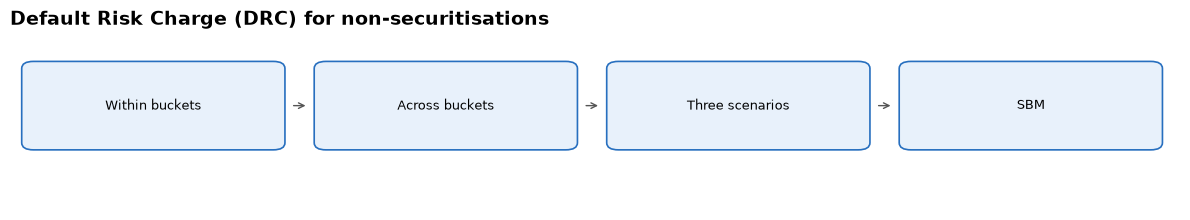

In [2]:
draw_flow(['Within buckets', 'Across buckets', 'Three scenarios', 'SBM'],'Default Risk Charge (DRC) for non-securitisations',wrap_after=4)

Calculate gross JTD trade by trade, apply permitted netting, separate net long and short JTD, risk-weight both sides, and discount the short-side benefit through HBR.

$$HBR=\frac{\text{net long JTD}}{\text{net long JTD}+|\text{net short JTD}|}$$

$$DRC_b=\text{weighted long}-HBR\times|\text{weighted short}|$$

In [3]:
gross=pd.read_csv(RUN/'11_drc_gross_jtd.csv'); net=pd.read_csv(RUN/'12_drc_net_jtd.csv'); buckets=pd.read_csv(RUN/'13_drc_bucket_results.csv')
gross_view=gross[gross.drc_class=='NON_SECURITISATION'].copy(); net_view=net[net.drc_class=='NON_SECURITISATION'].copy(); bucket_view=buckets[buckets.drc_class=='NON_SECURITISATION'].copy()
gross_view=gross_view.dropna(axis=1,how='all'); net_view=net_view.dropna(axis=1,how='all'); bucket_view=bucket_view.dropna(axis=1,how='all')
print('1. Gross trade-level JTD'); display(percent_columns(crore_table(gross_view,['gross_jtd']),['risk_weight']).fillna('Not applicable'))
print('2. Net JTD after permitted offsetting'); display(percent_columns(crore_table(net_view,['net_jtd']),['risk_weight']).fillna('Not applicable'))
print('3. HBR and risk-weighted bucket charge'); display(crore_table(bucket_view,['net_long_jtd','net_short_jtd','weighted_long','weighted_short','capital']))
print(f"Capital for this DRC class: INR {bucket_view.capital.sum()/INR_CRORE:,.4f} crore")

1. Gross trade-level JTD


,trade_id,drc_class,bucket,obligor,rating,seniority,maturity_scale,lgd,Gross Jtd (INR crore),Risk Weight (%)
0,R01,NON_SECURITISATION,SOVEREIGN,INDIA,BBB,SENIOR,1.0000,0.7500,7.4608,6.0000
1,R02,NON_SECURITISATION,SOVEREIGN,INDIA,BBB,SENIOR,1.0000,0.7500,11.2934,6.0000
2,R03,NON_SECURITISATION,SOVEREIGN,INDIA,BBB,SENIOR,1.0000,0.7500,-9.0472,6.0000
3,R04,NON_SECURITISATION,SOVEREIGN,US_GOV,AAA,SENIOR,1.0000,0.7500,12.9811,0.5000
4,R05,NON_SECURITISATION,SOVEREIGN,GERMANY,AAA,SENIOR,1.0000,0.7500,12.2578,0.5000
5,R11,NON_SECURITISATION,SOVEREIGN,INDIA,BBB,SENIOR,1.0000,0.7500,7.3569,6.0000
6,C01,NON_SECURITISATION,CORPORATE,AXIS_BANK,AA,SENIOR,1.0000,0.7500,7.2563,2.0000
7,C02,NON_SECURITISATION,CORPORATE,US_INDUSTRIAL,BBB,SENIOR,1.0000,0.7500,9.2296,6.0000
8,C03,NON_SECURITISATION,CORPORATE,EU_TECH,A,SENIOR,1.0000,0.7500,8.4093,3.0000
9,C04,NON_SECURITISATION,CORPORATE,INDIA_METALS,BB,SUBORDINATED,1.0000,1.0000,6.7413,15.0000


2. Net JTD after permitted offsetting


,drc_class,bucket,obligor,rating,seniority,Net Jtd (INR crore),Risk Weight (%)
0,NON_SECURITISATION,SOVEREIGN,INDIA,BBB,SENIOR,17.0639,6.0000
1,NON_SECURITISATION,SOVEREIGN,US_GOV,AAA,SENIOR,12.9811,0.5000
2,NON_SECURITISATION,SOVEREIGN,GERMANY,AAA,SENIOR,12.2578,0.5000
3,NON_SECURITISATION,CORPORATE,AXIS_BANK,AA,SENIOR,2.7359,2.0000
4,NON_SECURITISATION,CORPORATE,US_INDUSTRIAL,BBB,SENIOR,2.8475,6.0000
5,NON_SECURITISATION,CORPORATE,EU_TECH,A,SENIOR,8.4093,3.0000
6,NON_SECURITISATION,CORPORATE,INDIA_METALS,BB,SUBORDINATED,6.7413,15.0000
7,NON_SECURITISATION,CORPORATE,US_RETAIL,BBB,SENIOR,5.7617,6.0000
8,NON_SECURITISATION,CORPORATE,EU_UTILITY,A,SENIOR,5.7910,3.0000
9,NON_SECURITISATION,CORPORATE,RELIANCE,BBB,EQUITY,25.2611,6.0000


3. HBR and risk-weighted bucket charge


,drc_class,bucket,Net Long Jtd (INR crore),Net Short Jtd (INR crore),hbr,Weighted Long (INR crore),Weighted Short (INR crore),Capital (INR crore)
0,NON_SECURITISATION,CORPORATE,110.1777,0.0000,1.0000,7.0508,0.0000,7.0508
1,NON_SECURITISATION,SOVEREIGN,42.3029,0.0000,1.0000,1.1500,0.0000,1.1500


Capital for this DRC class: INR 8.2008 crore


The visual below uses the calculated rows shown above.

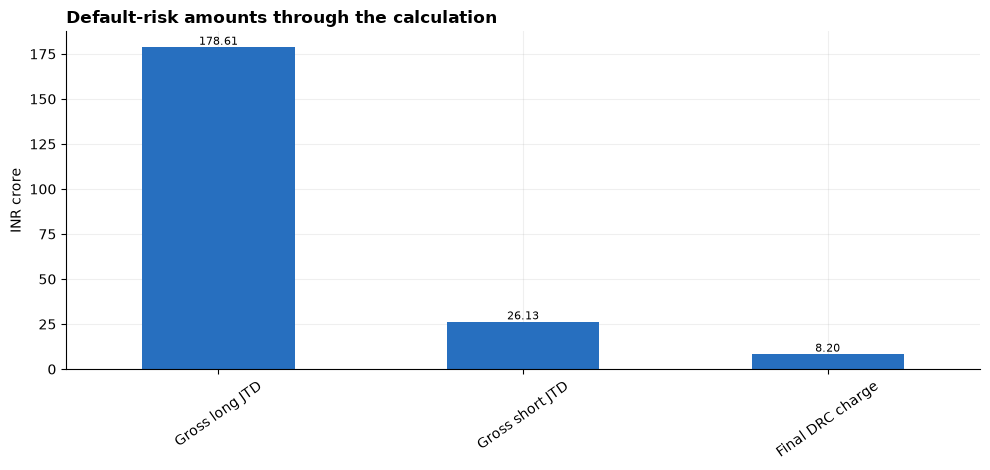

In [4]:
stages=pd.Series({'Gross long JTD':gross_view.loc[gross_view.gross_jtd>0,'gross_jtd'].sum(),
                          'Gross short JTD':abs(gross_view.loc[gross_view.gross_jtd<0,'gross_jtd'].sum()),
                          'Final DRC charge':bucket_view.capital.sum()})
bar_crore(stages,'Default-risk amounts through the calculation')

The charge remains separate from the other DRC classes and from CSR spread risk in SBM.